In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Memuat dataset
df = pd.read_csv('testcpns.csv')

# Menampilkan statistik deskriptif sesuai tabel soal
print(df.describe())

            toefl        ipk  pengalaman_kerja   diterima
count   40.000000  40.000000         40.000000  40.000000
mean   654.000000   2.694500          3.425000   0.475000
std     61.427464   0.653899          1.737778   0.505736
min    540.000000   1.070000          1.000000   0.000000
25%    607.500000   2.070000          2.000000   0.000000
50%    660.000000   3.030000          4.000000   0.000000
75%    690.000000   3.070000          5.000000   1.000000
max    780.000000   4.000000          6.000000   1.000000


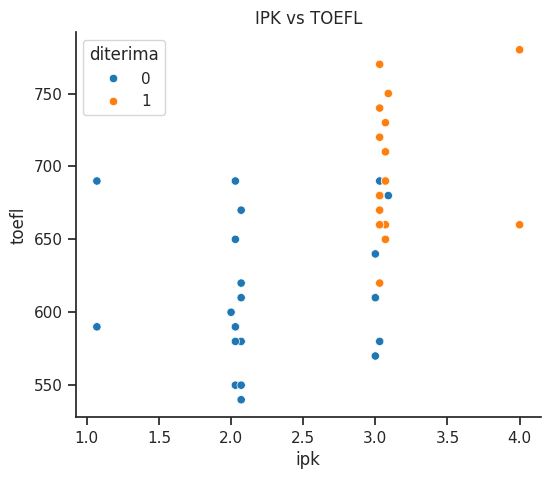

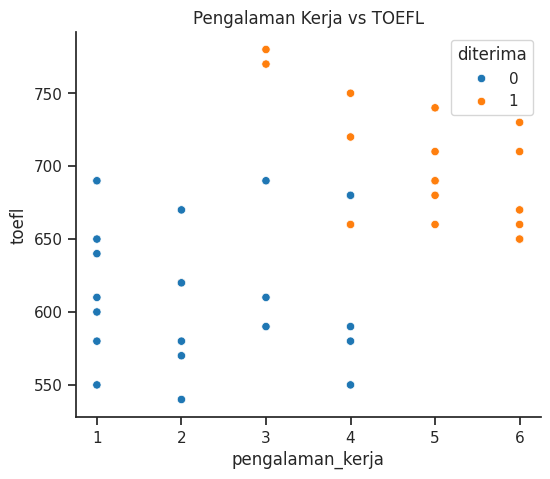

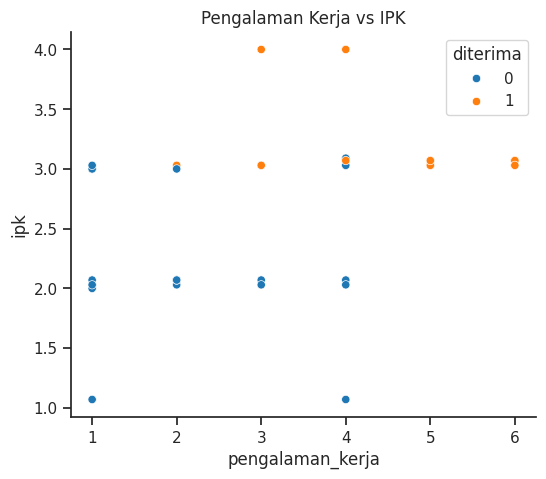

In [2]:
# Set gaya visualisasi
sns.set_theme(style="ticks")

# Plot 1: IPK vs TOEFL
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='ipk', y='toefl', hue='diterima', palette={0: '#1f77b4', 1: '#ff7f0e'})
sns.despine()
plt.title("IPK vs TOEFL")
plt.show()

# Plot 2: Pengalaman Kerja vs TOEFL
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='pengalaman_kerja', y='toefl', hue='diterima', palette={0: '#1f77b4', 1: '#ff7f0e'})
sns.despine()
plt.title("Pengalaman Kerja vs TOEFL")
plt.show()

# Plot 3: Pengalaman Kerja vs IPK
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='pengalaman_kerja', y='ipk', hue='diterima', palette={0: '#1f77b4', 1: '#ff7f0e'})
sns.despine()
plt.title("Pengalaman Kerja vs IPK")
plt.show()

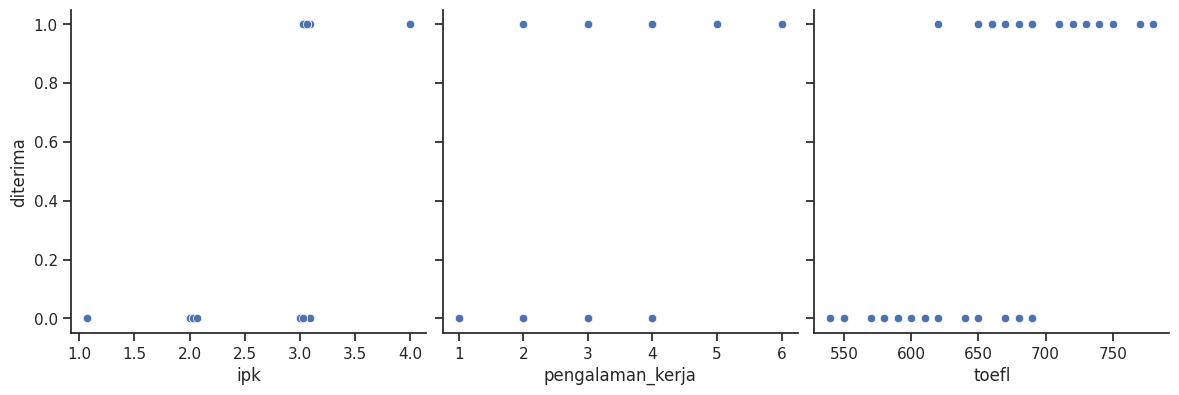

In [3]:
# Membuat pairplot linear sebaran terhadap target 'diterima'
g = sns.pairplot(df, x_vars=['ipk', 'pengalaman_kerja', 'toefl'], y_vars=['diterima'], height=4, aspect=1)
g.set(ylim=(-0.05, 1.05))
plt.show()

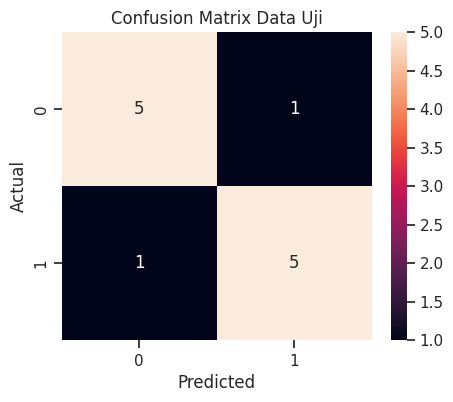

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# 1. Memisahkan Fitur dan Target
X = df[['toefl', 'ipk', 'pengalaman_kerja']]
y = df['diterima']

# 2. Membuat indeks data uji (test) sesuai baris yang diminta di tabel soal 5.e
test_indices = [22, 20, 25, 4, 10, 15, 28, 11, 18, 29, 27, 35]
train_indices = [i for i in df.index if i not in test_indices]

X_train, y_train = X.loc[train_indices], y.loc[train_indices]
X_test, y_test = X.loc[test_indices], y.loc[test_indices]

# 3. Melatih Model Regresi Logistik
model = LogisticRegression()
model.fit(X_train, y_train)

# 4. Melakukan Prediksi pada Data Uji
y_pred = model.predict(X_test)

# --- JAWABAN P5.d: CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='rocket', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Data Uji')
plt.show()

In [5]:
# --- JAWABAN P5.e: TABEL AKTUAL VS PREDIKSI ---
df_hasil = X_test.copy()
df_hasil['diterima_aktual'] = y_test
df_hasil['diterima_prediksi'] = y_pred

print("\nTabel Hasil Perbandingan Aktual vs Prediksi:")
display(df_hasil)


Tabel Hasil Perbandingan Aktual vs Prediksi:


,toefl,ipk,pengalaman_kerja,diterima_aktual,diterima_prediksi
22,550,2.03,4,0,0
20,620,3.03,2,1,0
25,670,3.03,6,1,1
4,680,3.09,4,0,1
10,610,2.07,3,0,0
15,610,3.00,1,0,0
28,650,3.07,6,1,1
11,690,3.07,5,1,1
18,650,3.07,6,1,1
29,660,3.03,5,1,1


In [7]:
# Data pelamar baru dari soal
pelamar_baru = pd.DataFrame([
    [590, 2.0, 3],
    [740, 3.07, 4],
    [680, 3.03, 6],
    [610, 2.03, 1],
    [710, 3.0, 5]
], columns=['toefl', 'ipk', 'pengalaman_kerja'])

# Melakukan prediksi
hasil_prediksi = model.predict(pelamar_baru)

# Menampilkan hasil ke dalam tabel
pelamar_baru['Prediksi Kelulusan'] = ['DITERIMA' if x == 1 else 'TIDAK DITERIMA' for x in hasil_prediksi]
print("\n--- HASIL PREDIKSI PELAMAR BARU (P5.f) ---")
display(pelamar_baru)


--- HASIL PREDIKSI PELAMAR BARU (P5.f) ---


,toefl,ipk,pengalaman_kerja,Prediksi Kelulusan
0,590,2.00,3,TIDAK DITERIMA
1,740,3.07,4,DITERIMA
2,680,3.03,6,DITERIMA
3,610,2.03,1,TIDAK DITERIMA
4,710,3.00,5,DITERIMA
